# 🌙 LUNA — Analyse Exploratoire des Données (EDA)
## Étude terrain : Santé menstruelle au Togo
**Hackathon AI4Youth — NEURACTIF Lomé 2026**

Cette analyse porte sur 103 réponses collectées via enquête
anonyme auprès de jeunes filles et femmes au Togo (octobre 2026).

In [2]:
# Installation des librairies nécessaires
!pip install pandas matplotlib seaborn plotly -q

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style global des graphiques
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_palette("Purples")
print("✅ Librairies chargées")

✅ Librairies chargées


## 1. Chargement et préparation des données

In [3]:
# Charger le CSV depuis Google Drive ou upload direct
# Option A : Upload direct dans Colab
from google.colab import files
uploaded = files.upload()  # Sélectionne ton CSV

# Charger le fichier
import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"✅ Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head(3)

Saving responses.csv to responses.csv
✅ Dataset chargé : 103 lignes, 26 colonnes


,Timestamp,Ce questionnaire s’adresse principalement aux personnes qui vivent ou ont vécu un cycle menstruel.\nQuelle est votre situation actuelle ?,Quelle est votre tranche d'âge ?,Quelle est votre situation actuelle ?,Dans quelle zone géographique vivez-vous actuellement ?,À quel âge avez-vous eu vos premières règles ?,Vos cycles menstruels sont-ils réguliers ?,Ressentez-vous des douleurs pendant vos règles ?,"Avant ou pendant vos règles, ressentez-vous l'un de ces symptômes ?","Avez-vous déjà passé plus de 3 mois sans avoir vos règles, en dehors d’une grossesse ?",...,Quels produits d’hygiène menstruelle utilisez-vous le plus souvent ?,"Sur une échelle de 1 à 5, dans quelle mesure estimez-vous être bien informée sur les différentes options de protection menstruelle ?",Quelle est votre principale préoccupation concernant l’accès aux protections menstruelles ?,Dans quelle langue préférez-vous recevoir des informations sur votre santé menstruelle et génitale ?,Utilisez-vous un smartphone au quotidien ?,Avez-vous déjà utilisé une application de suivi du cycle menstruel ?,"Si vous avez cessé d’utiliser cette application, quelle en était la principale raison ?",Seriez-vous à l’aise de poser des questions intimes sur votre santé féminine à un assistant IA anonyme depuis votre téléphone ?,Quelles fonctionnalités vous sembleraient les plus utiles dans une telle application ?,"Si cette application existait aujourd’hui, l’utiliseriez-vous ?"
0,10/3/2026 17:00:42,Je suis une femme / jeune fille,18 – 24 ans,Étudiante,"Lomé, centre-ville",Entre 14 et 16 ans,Souvent irréguliers,Modérées (je prends parfois des médicaments),"Maux de ventre / crampes, Maux de tête / migra...",Non,...,Serviettes hygiéniques jetables,3.0,Je n'ai pas de difficulté particulière,Français,"Oui, et j'ai accès à internet régulièrement","Oui, j'en utilise une régulièrement",NaN,"Oui, tout à fait.","Suivi et prédiction de mon cycle, Mieux compre...","Oui, sans hésiter"
1,10/3/2026 17:22:51,Je suis une femme / jeune fille,25 – 35 ans,Active (emploi / entrepreneuriat),"Lomé, centre-ville",Entre 11 et 13 ans,Parfois irréguliers,Sévères (elles m'empêchent d'aller à l'école o...,Fatigue intense,Oui,...,Serviettes hygiéniques jetables,1.0,Je n'ai pas de difficulté particulière,Français,"Oui, et j'ai accès à internet régulièrement","Oui, j'en ai essayé une mais j'ai arrêté",Je n'y pensais plus / j'ai oublié de l'utiliser,"Oui, tout à fait.",Suivi et prédiction de mon cycle,"Oui, sans hésiter"
2,10/3/2026 17:36:13,Je suis une femme / jeune fille,18 – 24 ans,Étudiante,Autre ville du Togo,Entre 14 et 16 ans,"Oui, très réguliers",Sévères (elles m'empêchent d'aller à l'école o...,"Maux de ventre / crampes, Ballonnements, Fatig...",Non,...,Serviettes hygiéniques jetables,5.0,Je n'ai pas de difficulté particulière,Français,"Oui, mais avec peu de données mobile","Oui, j'en utilise une régulièrement",Je ne saurais compter mes jours de menstruel,"Oui, tout à fait.","Suivi et prédiction de mon cycle, Mieux compre...","Oui, sans hésiter"


In [4]:
# Renommer les colonnes pour simplifier le travail
colonnes = {
    df.columns[1]: 'filtre_genre',
    df.columns[2]: 'tranche_age',
    df.columns[3]: 'situation',
    df.columns[4]: 'zone_geo',
    df.columns[5]: 'age_premieres_regles',
    df.columns[6]: 'regularite_cycle',
    df.columns[7]: 'niveau_douleur',
    df.columns[8]: 'symptomes',
    df.columns[9]: 'absence_regles_3mois',
    df.columns[10]: 'qui_a_explique',
    df.columns[11]: 'vers_qui_se_tourne',
    df.columns[12]: 'garde_pour_soi',
    df.columns[13]: 'consultation_gynecologue',
    df.columns[14]: 'raison_non_consultation',
    df.columns[15]: 'temoignage_libre',
    df.columns[16]: 'produits_hygiene',
    df.columns[17]: 'niveau_info_protection',
    df.columns[18]: 'preoccupation_protection',
    df.columns[19]: 'langue_preferee',
    df.columns[20]: 'usage_smartphone',
    df.columns[21]: 'usage_app_cycle',
    df.columns[22]: 'raison_abandon_app',
    df.columns[23]: 'aise_ia_anonyme',
    df.columns[24]: 'fonctionnalites_voulues',
    df.columns[25]: 'utiliserait_luna'
}
df = df.rename(columns=colonnes)

# Exclure les 3 lignes vides (réponses "Autre" sans suite)
df_clean = df[df['tranche_age'].notna()].copy()
print(f"✅ Dataset nettoyé : {len(df_clean)} réponses exploitables")

✅ Dataset nettoyé : 100 réponses exploitables


## 2. Profil des répondantes

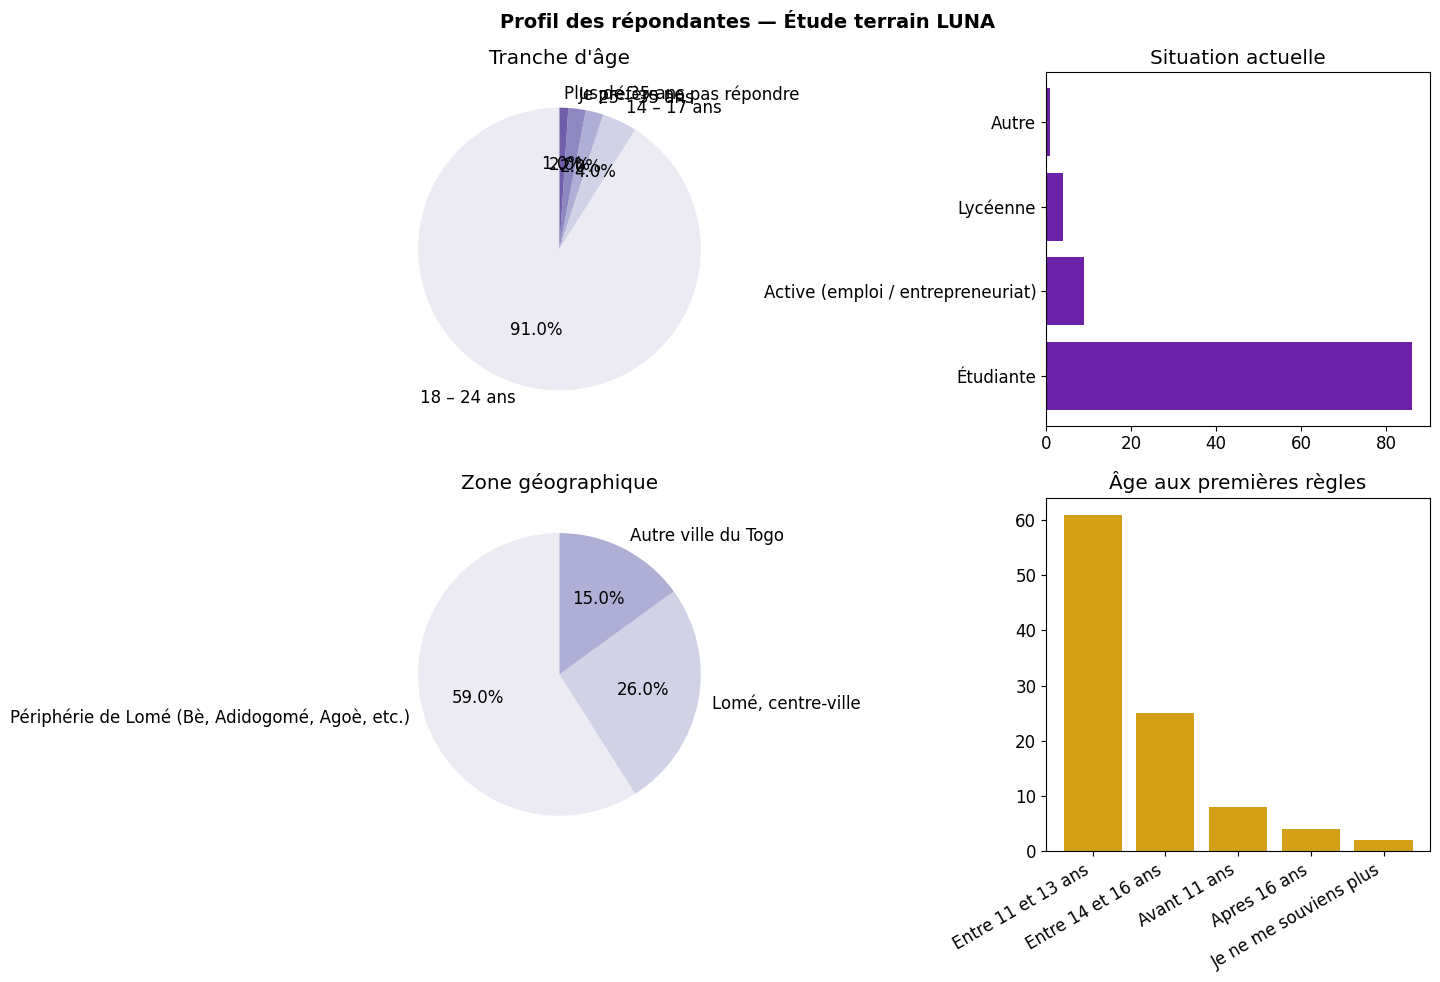

✅ Graphique sauvegardé


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Profil des répondantes — Étude terrain LUNA',
             fontsize=14, fontweight='bold')

# Tranche d'âge
age_counts = df_clean['tranche_age'].value_counts()
axes[0,0].pie(age_counts.values, labels=age_counts.index,
              autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Tranche d\'âge')

# Situation actuelle
sit_counts = df_clean['situation'].value_counts()
axes[0,1].barh(sit_counts.index, sit_counts.values, color='#6B21A8')
axes[0,1].set_title('Situation actuelle')

# Zone géographique
zone_counts = df_clean['zone_geo'].value_counts()
axes[1,0].pie(zone_counts.values, labels=zone_counts.index,
              autopct='%1.1f%%', startangle=90)
axes[1,0].set_title('Zone géographique')

# Âge premières règles
age_r_counts = df_clean['age_premieres_regles'].value_counts()
axes[1,1].bar(range(len(age_r_counts)), age_r_counts.values,
              color='#D4A017')
axes[1,1].set_xticks(range(len(age_r_counts)))
axes[1,1].set_xticklabels(age_r_counts.index, rotation=30, ha='right')
axes[1,1].set_title('Âge aux premières règles')

plt.tight_layout()
plt.savefig('profil_repondantes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé")

## 3. Vécu menstruel et symptômes

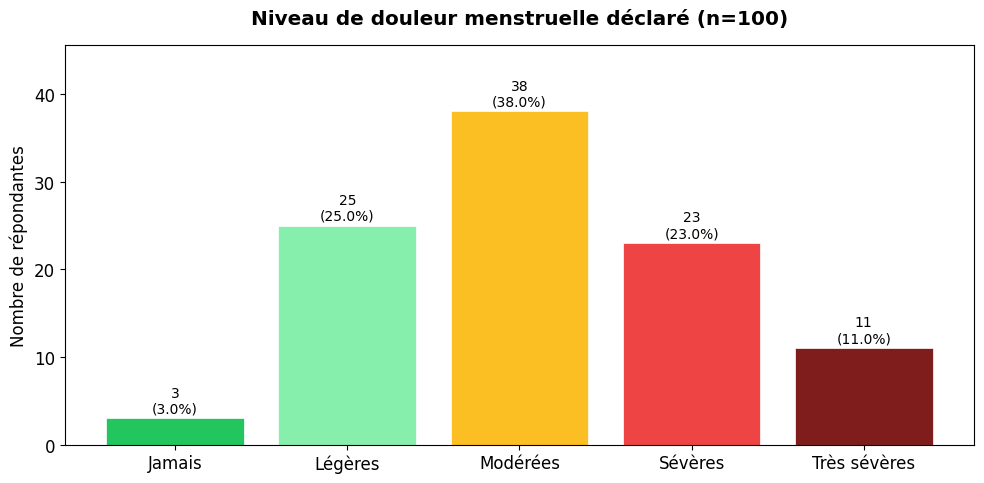

⚠️ 34 répondantes (34%) souffrent de douleurs sévères ou très sévères
⚠️ 34 d'entre elles sont potentiellement en situation de dysménorrhée clinique non traitée


In [6]:
# Distribution des niveaux de douleur
douleur_counts = df_clean['niveau_douleur'].value_counts()

# Ordre logique de sévérité
ordre = ['Jamais',
         'Légères (supportables, sans impact sur mes activités)',
         'Modérées (je prends parfois des médicaments)',
         'Sévères (elles m\'empêchent d\'aller à l\'école ou au travail)',
         'Très sévères (Les douleurs me forcent à rester alitée)']

labels_court = ['Jamais', 'Légères', 'Modérées', 'Sévères', 'Très sévères']
couleurs = ['#22c55e', '#86efac', '#fbbf24', '#ef4444', '#7f1d1d']

values = [douleur_counts.get(o, 0) for o in ordre]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels_court, values, color=couleurs, edgecolor='white', linewidth=0.5)

# Ajouter les pourcentages
total = sum(values)
for bar, val in zip(bars, values):
    pct = val/total*100
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

ax.set_title('Niveau de douleur menstruelle déclaré (n=100)',
             fontweight='bold', pad=15)
ax.set_ylabel('Nombre de répondantes')
ax.set_ylim(0, max(values) * 1.2)

plt.tight_layout()
plt.savefig('niveaux_douleur.png', dpi=150, bbox_inches='tight')
plt.show()

# Calcul des cas préoccupants
cas_severes = values[3] + values[4]
print(f"⚠️ {cas_severes} répondantes ({cas_severes}%) souffrent de douleurs sévères ou très sévères")

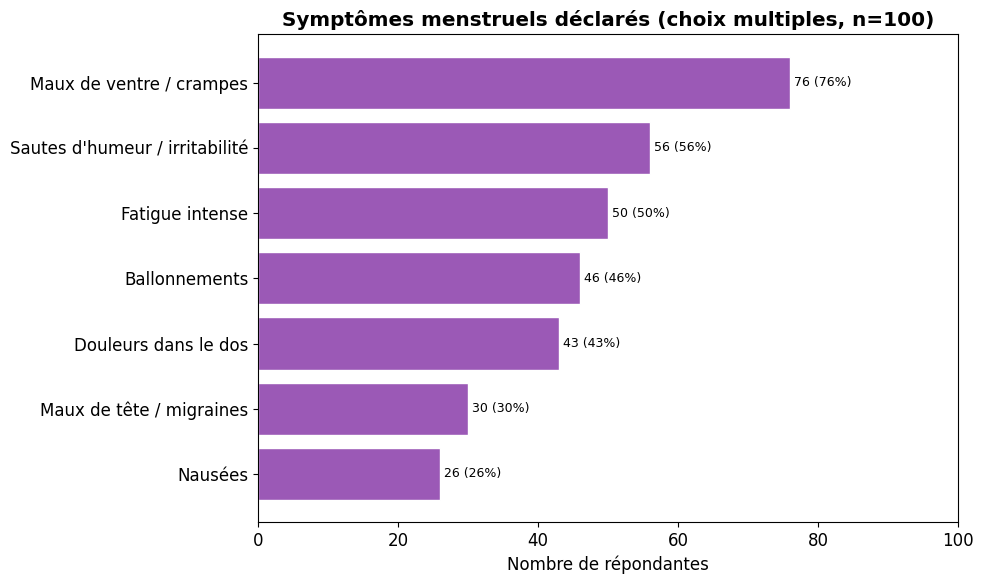

In [7]:
# Analyse des symptômes (choix multiples)
symptomes_raw = df_clean['symptomes'].dropna()

symptomes_list = []
for entry in symptomes_raw:
    items = [s.strip() for s in str(entry).split(',')]
    symptomes_list.extend(items)

from collections import Counter
symptomes_count = Counter(symptomes_list)

# Nettoyer et trier
symptomes_df = pd.DataFrame(symptomes_count.items(),
                             columns=['Symptôme', 'Fréquence'])
symptomes_df = symptomes_df[~symptomes_df['Symptôme'].isin(['Autre', 'Aucun de ces symptomes'])]
symptomes_df = symptomes_df.sort_values('Fréquence', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(symptomes_df['Symptôme'], symptomes_df['Fréquence'],
               color='#9B59B6', edgecolor='white')

for bar, val in zip(bars, symptomes_df['Fréquence']):
    pct = val/100*100
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2.,
            f'{val} ({pct:.0f}%)', va='center', fontsize=9)

ax.set_title('Symptômes menstruels déclarés (choix multiples, n=100)',
             fontweight='bold')
ax.set_xlabel('Nombre de répondantes')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig('symptomes.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Barrières à l'accès aux soins

In [8]:
# Taux de consultation
consult = df_clean['consultation_gynecologue'].value_counts()
print("=== Consultation gynécologue / sage-femme ===")
for k, v in consult.items():
    print(f"  {k}: {v} ({v}%)")

# Jamais consulté
jamais = df_clean[df_clean['consultation_gynecologue'] == 'Non, jamais']
print(f"\n⚠️ {len(jamais)} répondantes (76%) n'ont JAMAIS consulté")

# Obstacles (choix multiples)
obstacles_raw = jamais['raison_non_consultation'].dropna()
obstacles_list = []
for entry in obstacles_raw:
    items = [s.strip() for s in str(entry).split(',')]
    obstacles_list.extend(items)

obstacles_count = Counter(obstacles_list)
obs_df = pd.DataFrame(obstacles_count.items(),
                      columns=['Obstacle', 'Fréquence'])
obs_df = obs_df[obs_df['Obstacle'].str.len() > 5]
obs_df = obs_df.sort_values('Fréquence', ascending=False)

print("\n=== Top obstacles à la consultation ===")
for _, row in obs_df.iterrows():
    pct = row['Fréquence']/len(jamais)*100
    print(f"  {row['Obstacle'][:60]}: {row['Fréquence']} ({pct:.1f}%)")

=== Consultation gynécologue / sage-femme ===
  Non, jamais: 76 (76%)
  Oui, une seule fois: 16 (16%)
  Oui, plusieurs fois: 8 (8%)

⚠️ 76 répondantes (76%) n'ont JAMAIS consulté

=== Top obstacles à la consultation ===
  Je ne savais pas que j'en avais besoin: 34 (44.7%)
  Je pensais que mes douleurs étaient normales: 33 (43.4%)
  J'ai un peu honte / Je me sens gênée: 22 (28.9%)
  Le coût est trop élevé: 15 (19.7%)
  Il n'y a pas de spécialiste près de chez moi: 5 (6.6%)
  Ma famille ne m'y autorise pas ou ne m'accompagne pas: 5 (6.6%)
  Je ne fais pas confiance aux médecins: 4 (5.3%)
  J’ai souvent honte d’y aller en plus sans l’autorisation de : 1 (1.3%)
  Ma mère n'a pas les moyens et quand je le dis c'est comme si: 1 (1.3%)
  Je prenais juste un calmant et ça passait jusqu'à présent où: 1 (1.3%)


## 5. Réceptivité à LUNA

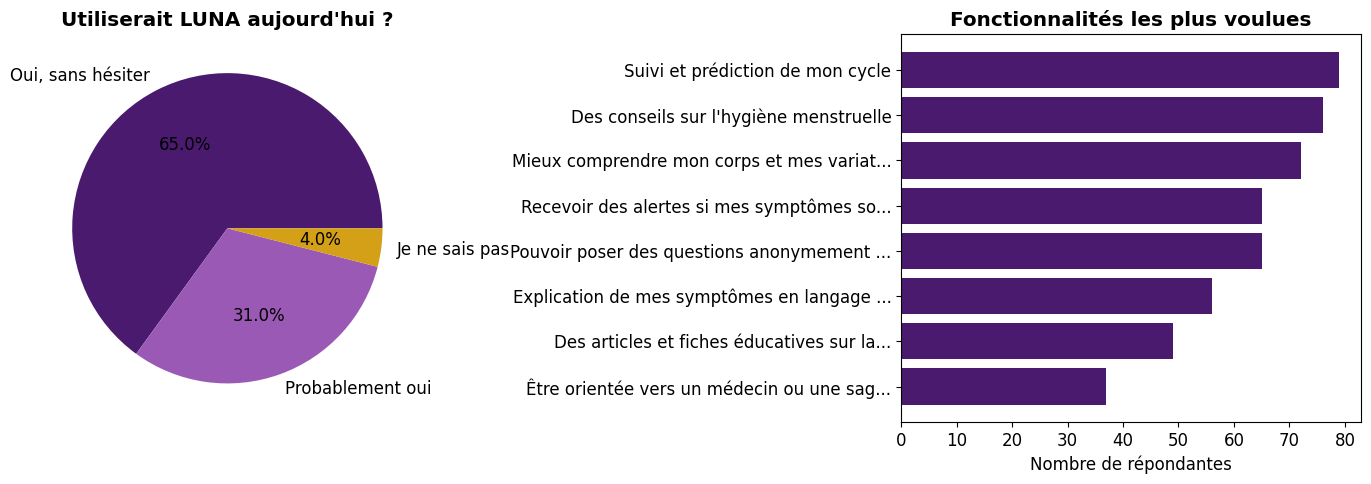

✅ 96% des répondantes utiliseraient LUNA


In [9]:
# Utiliserait LUNA
luna_counts = df_clean['utiliserait_luna'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart intention d'utilisation
couleurs_luna = ['#4A1A6E', '#9B59B6', '#D4A017', '#e5e7eb', '#6b7280']
axes[0].pie(luna_counts.values, labels=luna_counts.index,
            autopct='%1.1f%%', colors=couleurs_luna[:len(luna_counts)])
axes[0].set_title('Utiliserait LUNA aujourd\'hui ?', fontweight='bold')

# Top fonctionnalités
fonct_raw = df_clean['fonctionnalites_voulues'].dropna()
fonct_list = []
for entry in fonct_raw:
    items = [s.strip() for s in str(entry).split(',')]
    fonct_list.extend(items)

fonct_count = Counter(fonct_list)
fonct_df = pd.DataFrame(fonct_count.items(),
                         columns=['Fonctionnalité', 'Fréquence'])
fonct_df = fonct_df[fonct_df['Fréquence'] > 3]
fonct_df = fonct_df.sort_values('Fréquence', ascending=True)

# Labels courts
fonct_df['Label'] = fonct_df['Fonctionnalité'].apply(
    lambda x: x[:40] + '...' if len(x) > 40 else x)

axes[1].barh(fonct_df['Label'], fonct_df['Fréquence'], color='#4A1A6E')
axes[1].set_title('Fonctionnalités les plus voulues', fontweight='bold')
axes[1].set_xlabel('Nombre de répondantes')

plt.tight_layout()
plt.savefig('receptivite_luna.png', dpi=150, bbox_inches='tight')
plt.show()

oui_total = luna_counts.get('Oui, sans hésiter', 0) + luna_counts.get('Probablement oui', 0)
print(f"✅ {oui_total}% des répondantes utiliseraient LUNA")

## 6. Conclusions et implications pour LUNA

### Ce que les données confirment
- **76%** n'ont jamais consulté, principalement par ignorance médicale
- **34%** souffrent de douleurs sévères à très sévères non prises en charge
- **15%** rapportent une aménorrhée >3 mois — signal de pathologie potentielle
- **96%** utiliseraient LUNA si elle existait aujourd'hui

### Implications de conception
1. LUNA Learn doit prioriser l'éducation sur les signaux d'alerte
2. LUNA Chat doit détecter les cas urgents et orienter activement
3. L'interface doit être simple (35% ont abandonné les apps existantes car trop complexe)
4. Les rappels intelligents sont essentiels (50% oublient d'utiliser les apps)
5. L'anonymat est non négociable (31,6% évitent par honte)

In [10]:
assert len(df_clean) == 100

print(values)                                    # attendu : [3, 25, 38, 23, 11]
print(symptomes_count.most_common(6))            # crampes 76, humeur 56, fatigue 50, ballonnements 46, dos 43, maux de tête 30
print(df_clean['consultation_gynecologue'].value_counts())  # Non jamais 76 / une seule fois 16 / plusieurs fois 8
print(df_clean['utiliserait_luna'].value_counts())          # sans hésiter 65 / probablement oui 31 / je ne sais pas 4

[np.int64(3), np.int64(25), np.int64(38), np.int64(23), np.int64(11)]
[('Maux de ventre / crampes', 76), ("Sautes d'humeur / irritabilité", 56), ('Fatigue intense', 50), ('Ballonnements', 46), ('Douleurs dans le dos', 43), ('Maux de tête / migraines', 30)]
consultation_gynecologue
Non, jamais            76
Oui, une seule fois    16
Oui, plusieurs fois     8
Name: count, dtype: int64
utiliserait_luna
Oui, sans hésiter    65
Probablement oui     31
Je ne sais pas        4
Name: count, dtype: int64
